--- Bias Assessment Mean Feature Contributions (Log Odds) ---
       Feature  Contribution_NoDefault  Contribution_Default  Contribution_Difference
   CreditScore                 -0.6700                0.7229                   1.3929
        Income                 -0.2498                0.2695                   0.5194
   HasMortgage                 -0.2113                0.2280                   0.4393
MonthsEmployed                 -0.1150                0.1241                   0.2392
    LoanAmount                 -0.0913                0.0985                   0.1898
NumCreditLines                 -0.0085                0.0091                   0.0176
           Age                  0.0001               -0.0001                  -0.0003


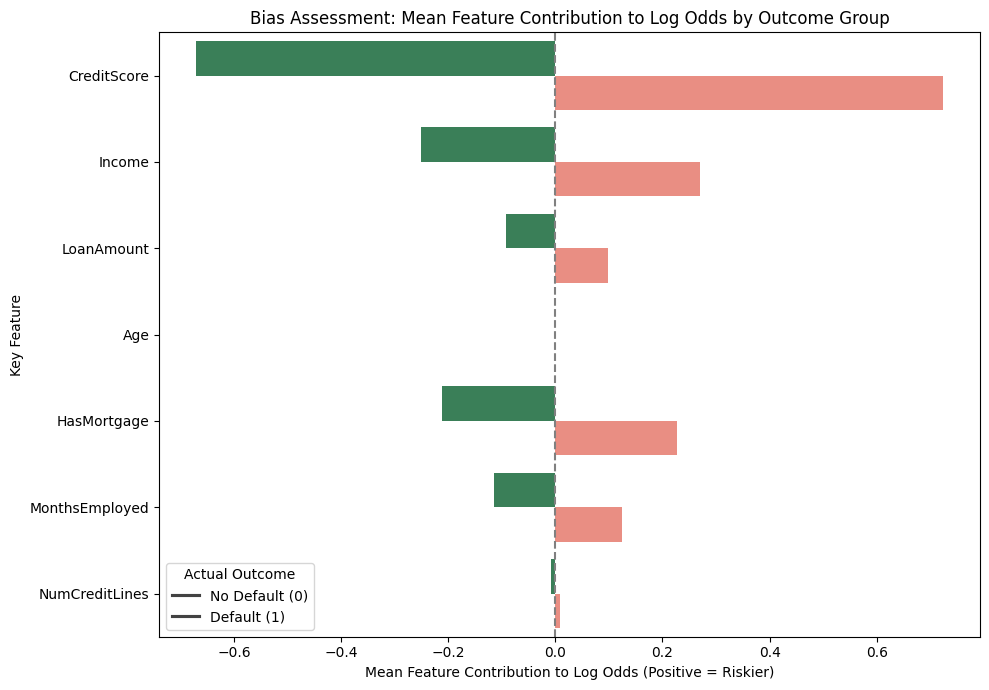

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier

# ==============================================================================
# 1. DATA LOADING, CLEANING, AND SETUP
# ==============================================================================

# Load the dataset
df = pd.read_csv(r"C:/Users/hp/Downloads/Credit_Risk.csv")

# Data Cleaning: Handle negative values in 'Income' and 'LoanAmount' by replacing with NaN
df['Income'] = np.where(df['Income'] < 0, np.nan, df['Income'])
df['LoanAmount'] = np.where(df['LoanAmount'] < 0, np.nan, df['LoanAmount'])

# Define Features and Target
X = df.drop('Default', axis=1)
y = df['Default']

numerical_features = ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'HasMortgage', 'HasDependents', 'HasCoSigner']
categorical_features = ['LoanPurpose']

# --- Preprocessing Pipeline Setup ---
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(missing_values=np.nan, strategy='median')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop'
)

# --- Best Model (Logistic Regression) Pipeline ---
# LR was identified as the best-performing model
best_model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, solver='liblinear'))
])

# Fit the model on the entire dataset for explanation
best_model_pipeline.fit(X, y)

# ==============================================================================
# 2. EXTRACT COMPONENTS AND CALCULATE CONTRIBUTIONS (SHAP Equivalent)
# ==============================================================================

logreg_model = best_model_pipeline['classifier']
X_transformed = best_model_pipeline['preprocessor'].transform(X)

# Extract feature names
transformed_feature_names = best_model_pipeline['preprocessor'].get_feature_names_out()
feature_names = [name.split('__')[-1] for name in transformed_feature_names]

# Extract coefficients
coefficients = logreg_model.coef_[0]

# Calculate all feature contributions (Beta * X)
all_contributions = X_transformed * coefficients

# Convert to DataFrame and add the target variable
contributions_df = pd.DataFrame(all_contributions, index=df.index, columns=feature_names)
contributions_df['Default'] = y

# ==============================================================================
# 3. BIAS ASSESSMENT: COMPARE MEAN CONTRIBUTIONS BY OUTCOME GROUP
# ==============================================================================

# Group and calculate mean contribution
mean_contributions = contributions_df.groupby('Default').mean()

# Select key features for assessment (same set as previous successful step)
key_features_assessment = ['CreditScore', 'Income', 'LoanAmount', 'Age', 'HasMortgage', 'MonthsEmployed', 'NumCreditLines']

# Focus on the mean contribution of these features across the two groups
bias_df = mean_contributions[key_features_assessment].T.reset_index()
bias_df.columns = ['Feature', 'Contribution_NoDefault', 'Contribution_Default']

# Calculate the difference (Bias = Default - NoDefault)
bias_df['Contribution_Difference'] = bias_df['Contribution_Default'] - bias_df['Contribution_NoDefault']

# --- Generate Final Table ---
print("--- Bias Assessment Mean Feature Contributions (Log Odds) ---")
print(bias_df.sort_values(by='Contribution_Difference', ascending=False).to_string(index=False, float_format='%.4f'))

# ==============================================================================
# 4. VISUALIZATION
# ==============================================================================

# Melt the DataFrame for plotting
plot_df = bias_df.melt(id_vars='Feature', 
                       value_vars=['Contribution_NoDefault', 'Contribution_Default'],
                       var_name='Outcome_Group', 
                       value_name='Mean_Contribution_LogOdds')
plot_df['Outcome_Group'] = plot_df['Outcome_Group'].str.replace('Contribution_', '')

plt.figure(figsize=(10, 7))
sns.barplot(x='Mean_Contribution_LogOdds', y='Feature', hue='Outcome_Group', data=plot_df, palette={'NoDefault': 'seagreen', 'Default': 'salmon'})
plt.axvline(x=0, color='grey', linestyle='--')
plt.title('Bias Assessment: Mean Feature Contribution to Log Odds by Outcome Group')
plt.xlabel('Mean Feature Contribution to Log Odds (Positive = Riskier)')
plt.ylabel('Key Feature')
plt.legend(title='Actual Outcome', labels=['No Default (0)', 'Default (1)'])
plt.tight_layout()
plt.show() # Display the final expected plot